In [14]:
%matplotlib inline

In [15]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import time

In [16]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Config

In [17]:
import os
import random
import shutil
import glob
import numpy as np
import torch
from google.colab import drive

# =========================
# Google Drive
# =========================

drive.mount("/content/drive")

# =========================
# Fast Config for Colab + task_3_point_transformer
# =========================

CFG = {
    # Paths
    "drive_dataset_dir": "/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_3_point_transformer/dataset",
    "drive_output_dir": "/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_3_point_transformer/output",

    # Local Colab paths
    "dataset_dir": "/content/dataset",
    "output_dir": "/content/output",

    # Files
    "file_pattern": "valve_*_lidar_classes.ply",

    # Dataset
    "num_classes": 14,

    # Sampling
    "num_points": 4096,

    # Training
    # 45 эпох при ~18-22 сек/эпоха даст примерно 13-17 минут
    "batch_size": 16,
    "epochs": 45,
    "lr": 5e-4,
    "weight_decay": 1e-4,

    # При 45 эпохах scheduler лучше двигать медленнее
    "scheduler_step": 15,
    "scheduler_gamma": 0.5,

    # Early stopping почти не будет мешать
    "patience": 15,

    # Point Transformer
    "k": 16,
    "pt_dims": [32, 64, 128, 256],
    "npoints": [4096, 1024, 256, 64],
    "dropout": 0.5,

    # Split ratios
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # Reproducibility
    "seed": 42,

    # Workers
    "num_workers": 2,

    # Speed
    "use_amp": True,
}





# =========================
# Reproducibility
# =========================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Для скорости лучше benchmark=True
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(CFG["seed"])


# =========================
# Device
# =========================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =========================
# Copy dataset from Drive to local Colab
# =========================

if not os.path.exists(CFG["drive_dataset_dir"]):
    raise FileNotFoundError(f"Drive dataset folder not found: {CFG['drive_dataset_dir']}")

os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(CFG["drive_output_dir"], exist_ok=True)

if not os.path.exists(CFG["dataset_dir"]):
    print("Copying dataset from Google Drive to local Colab...")
    shutil.copytree(CFG["drive_dataset_dir"], CFG["dataset_dir"])
    print("Dataset copied.")
else:
    print("Local dataset already exists.")

print("Local dataset dir:", CFG["dataset_dir"])
print("Local output dir:", CFG["output_dir"])
print("Drive output dir:", CFG["drive_output_dir"])


# =========================
# Check files
# =========================

all_files = sorted(
    glob.glob(
        os.path.join(CFG["dataset_dir"], CFG["file_pattern"])
    )
)

print(f"Found {len(all_files)} PLY files")

if len(all_files) == 0:
    raise RuntimeError("No PLY files found. Check dataset_dir or file_pattern.")


# =========================
# Compatibility variables
# =========================

NUM_POINTS = CFG["num_points"]
NUM_CLASSES = CFG["num_classes"]
BATCH_SIZE = CFG["batch_size"]
EPOCHS = CFG["epochs"]
LR = CFG["lr"]
WEIGHT_DECAY = CFG["weight_decay"]
STEP_SIZE = CFG["scheduler_step"]
GAMMA = CFG["scheduler_gamma"]
PATIENCE = CFG["patience"]

print("NUM_POINTS:", NUM_POINTS)
print("NUM_CLASSES:", NUM_CLASSES)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("k:", CFG["k"])
print("pt_dims:", CFG["pt_dims"])
print("npoints:", CFG["npoints"])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
Local dataset already exists.
Local dataset dir: /content/dataset
Local output dir: /content/output
Drive output dir: /content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_3_point_transformer/output
Found 500 PLY files
NUM_POINTS: 4096
NUM_CLASSES: 14
BATCH_SIZE: 16
EPOCHS: 45
k: 16
pt_dims: [32, 64, 128, 256]
npoints: [4096, 1024, 256, 64]


## PLY Loader

In [18]:
def load_ply(filepath):
    """
    Load ASCII .ply with x, y, z, scalar_Label.
    Returns:
        points  – (N, 3) float32
        labels  – (N,)   int64
    """
    with open(filepath, "r") as f:
        line = f.readline().strip()
        assert line == "ply", f"Not a PLY file: {filepath}"

        num_vertices = None
        while True:
            line = f.readline().strip()
            if line.startswith("element vertex"):
                num_vertices = int(line.split()[-1])
            if line == "end_header":
                break

        assert num_vertices is not None, f"Could not parse vertex count in {filepath}"

        points = np.empty((num_vertices, 3), dtype=np.float32)
        labels = np.empty(num_vertices, dtype=np.int64)

        for i in range(num_vertices):
            parts = f.readline().strip().split()
            points[i, 0] = float(parts[0])
            points[i, 1] = float(parts[1])
            points[i, 2] = float(parts[2])
            labels[i] = int(parts[3])

    return points, labels


## Dataset investigation

In [19]:
def investigate_dataset(file_list):
    """Scan all files to find class set, counts, and per-file point stats."""
    global_counts = Counter()
    point_counts = []

    for fp in file_list:
        _, labels = load_ply(fp)
        point_counts.append(len(labels))
        for lbl in labels:
            global_counts[lbl] += 1

    classes = sorted(global_counts.keys())
    num_classes = len(classes)
    total_points = sum(global_counts.values())

    print("=" * 60)
    print("DATASET INVESTIGATION")
    print("=" * 60)
    print(f"Files           : {len(file_list)}")
    print(f"Points/file     : min={min(point_counts)}, max={max(point_counts)}, "
          f"mean={np.mean(point_counts):.0f}")
    print(f"Classes found   : {classes}")
    print(f"Num classes     : {num_classes}")
    print(f"Total points    : {total_points}")
    print("-" * 60)
    print(f"{'Class':>7}  {'Count':>12}  {'Fraction':>10}")
    print("-" * 60)
    for c in classes:
        print(f"{c:>7}  {global_counts[c]:>12,}  "
              f"{global_counts[c] / total_points:>10.4f}")
    print("=" * 60)

    counts_arr = np.array([global_counts[c] for c in classes], dtype=np.float64)
    inv_freq = total_points / (num_classes * counts_arr)
    inv_freq = inv_freq / np.median(inv_freq)
    inv_freq = np.clip(inv_freq, 0.5, 5.0)
    print(f"CE weights      : {np.round(inv_freq, 4).tolist()}")

    return num_classes, classes, inv_freq

## Dataset preprocessing

In [20]:
class PointCloudDataset(Dataset):
    """
    Loads PLY files, normalises, samples fixed number of points.
    Returns (B, N, 3) for Point Transformer (channels-last).
    """

    def __init__(self, file_list, num_points=4096, augment=False):
        super().__init__()
        self.file_list = file_list
        self.num_points = num_points
        self.augment = augment
        self.data = []
        for fp in file_list:
            pts, lbl = load_ply(fp)
            self.data.append((pts, lbl))

    def __len__(self):
        return len(self.data)

    def _normalize(self, points):
        centroid = points.mean(axis=0)
        points = points - centroid
        max_dist = np.max(np.linalg.norm(points, axis=1))
        if max_dist > 0:
            points = points / max_dist
        return points

    @staticmethod
    def _apply_augment_transforms(points):
        angle_y = np.random.uniform(0, 2 * np.pi)
        angle_x = np.random.uniform(-np.pi / 18, np.pi / 18)
        angle_z = np.random.uniform(-np.pi / 18, np.pi / 18)

        Ry = np.array([
            [np.cos(angle_y), 0, np.sin(angle_y)],
            [0, 1, 0],
            [-np.sin(angle_y), 0, np.cos(angle_y)]
        ], dtype=np.float32)

        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(angle_x), -np.sin(angle_x)],
            [0, np.sin(angle_x), np.cos(angle_x)]
        ], dtype=np.float32)

        Rz = np.array([
            [np.cos(angle_z), -np.sin(angle_z), 0],
            [np.sin(angle_z), np.cos(angle_z), 0],
            [0, 0, 1]
        ], dtype=np.float32)

        R = Rz @ Ry @ Rx
        points = points @ R.T

        scale = np.random.uniform(0.8, 1.2)
        points = points * scale

        jitter = np.random.normal(0, 0.01, size=points.shape).astype(np.float32)
        jitter = np.clip(jitter, -0.05, 0.05)
        points = points + jitter

        return points

    def __getitem__(self, idx):
        points, labels = self.data[idx]
        points = points.copy()
        labels = labels.copy()

        points = self._normalize(points)

        N = len(points)
        if N >= self.num_points:
            choice = np.random.choice(N, self.num_points, replace=False)
        else:
            choice = np.random.choice(N, self.num_points, replace=True)

        points = points[choice]
        labels = labels[choice]

        if self.augment:
            perm = np.random.permutation(self.num_points)
            points = points[perm]
            labels = labels[perm]
            points = self._apply_augment_transforms(points)

        # Point Transformer uses (N, 3) — channels-last
        points = torch.from_numpy(points).float()       # (N, 3)
        labels = torch.from_numpy(labels).long()         # (N,)
        return points, labels

## Model

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Point Transformer v1 (Zhao et al., ICCV 2021) adapted for
#  small-scale per-point segmentation.
#
#  Encoder stages with Transition-Down (FPS + local MLP + pool)
#  Decoder stages with Transition-Up   (interpolation + skip)
#  Each stage wraps a Point Transformer Block (vector self-attention).
# ═══════════════════════════════════════════════════════════════════════════════


def farthest_point_sample(xyz, npoint):
    """
    Farthest Point Sampling.
    xyz : (B, N, 3)
    returns : (B, npoint) long indices
    """
    B, N, _ = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=xyz.device)
    distance = torch.full((B, N), 1e10, device=xyz.device)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=xyz.device)
    batch_idx = torch.arange(B, dtype=torch.long, device=xyz.device)

    for i in range(npoint):
        centroids[:, i] = farthest
        centroid_xyz = xyz[batch_idx, farthest, :].unsqueeze(1)   # (B,1,3)
        dist = torch.sum((xyz - centroid_xyz) ** 2, dim=-1)       # (B,N)
        distance = torch.min(distance, dist)
        farthest = distance.max(dim=-1)[1]

    return centroids


def index_points(points, idx):
    """
    Gather points by index.
    points : (B, N, C)
    idx    : (B, S) or (B, S, K)
    returns: (B, S, C) or (B, S, K, C)
    """
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = (torch.arange(B, dtype=torch.long, device=points.device)
                     .view(view_shape).repeat(repeat_shape))
    return points[batch_indices, idx, :]


def knn_point(k, query, ref):
    """
    KNN search.
    query : (B, M, 3)
    ref   : (B, N, 3)
    returns : (B, M, k) indices into ref
    """
    dist = torch.cdist(query, ref)          # (B, M, N)
    _, idx = dist.topk(k, dim=-1, largest=False)
    return idx


def three_nn_interpolate(xyz_target, xyz_source, feat_source):
    """
    Inverse-distance-weighted interpolation from source to target using 3-NN.
    xyz_target  : (B, M, 3)
    xyz_source  : (B, S, 3)
    feat_source : (B, S, C)
    returns     : (B, M, C)
    """
    idx = knn_point(3, xyz_target, xyz_source)       # (B, M, 3)
    nn_xyz = index_points(xyz_source, idx)           # (B, M, 3, 3)
    diff = xyz_target.unsqueeze(2) - nn_xyz          # (B, M, 3, 3)
    dist = torch.sqrt((diff ** 2).sum(dim=-1).clamp(min=1e-10))  # (B, M, 3)
    weight = 1.0 / dist                             # (B, M, 3)
    weight = weight / weight.sum(dim=-1, keepdim=True)           # normalise

    nn_feat = index_points(feat_source, idx)         # (B, M, 3, C)
    interp = (weight.unsqueeze(-1) * nn_feat).sum(dim=2)         # (B, M, C)
    return interp


# ── Point Transformer Block (vector self-attention) ──────────────────────────

class PointTransformerBlock(nn.Module):
    """
    Local vector self-attention with learned positional encoding.
    """

    def __init__(self, dim, k=16):
        super().__init__()
        self.k = k

        self.fc_q = nn.Linear(dim, dim)
        self.fc_k = nn.Linear(dim, dim)
        self.fc_v = nn.Linear(dim, dim)

        self.pos_enc = nn.Sequential(
            nn.Linear(3, dim),
            nn.ReLU(inplace=True),
            nn.Linear(dim, dim),
        )

        self.attn_mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(inplace=True),
            nn.Linear(dim, dim),
        )

        self.ff = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(inplace=True),
            nn.Linear(dim, dim),
        )

        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x, xyz):
        """
        x   : (B, N, C)
        xyz : (B, N, 3)
        returns : (B, N, C)
        """
        residual = x
        x = self.norm1(x)

        q = self.fc_q(x)          # (B, N, C)
        k = self.fc_k(x)          # (B, N, C)
        v = self.fc_v(x)          # (B, N, C)

        # KNN neighbours
        knn_idx = knn_point(self.k, xyz, xyz)           # (B, N, k)
        k_grouped = index_points(k, knn_idx)            # (B, N, k, C)
        v_grouped = index_points(v, knn_idx)            # (B, N, k, C)
        xyz_grouped = index_points(xyz, knn_idx)        # (B, N, k, 3)

        # Positional encoding from relative positions
        pos_diff = xyz.unsqueeze(2) - xyz_grouped       # (B, N, k, 3)
        pe = self.pos_enc(pos_diff)                     # (B, N, k, C)

        # Vector attention weights
        attn = self.attn_mlp(
            q.unsqueeze(2) - k_grouped + pe
        )                                                # (B, N, k, C)
        attn = F.softmax(attn, dim=2)                   # softmax over k

        # Aggregate
        out = (attn * (v_grouped + pe)).sum(dim=2)      # (B, N, C)
        out = out + residual

        # Feed-forward
        residual2 = out
        out = self.norm2(out)
        out = self.ff(out) + residual2

        return out


# ── Transition Down (encoder down-sampling) ──────────────────────────────────

class TransitionDown(nn.Module):
    """FPS → KNN local → MLP → max-pool  to reduce point count."""

    def __init__(self, in_dim, out_dim, npoint, k=16):
        super().__init__()
        self.npoint = npoint
        self.k = k
        self.mlp = nn.Sequential(
            nn.Linear(in_dim + 3, out_dim),
            nn.ReLU(inplace=True),
            nn.Linear(out_dim, out_dim),
        )
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x, xyz):
        """
        x   : (B, N, C_in)
        xyz : (B, N, 3)
        returns : (x_new (B, npoint, C_out),  xyz_new (B, npoint, 3))
        """
        fps_idx = farthest_point_sample(xyz, self.npoint)        # (B, npoint)
        xyz_new = index_points(xyz, fps_idx)                     # (B, npoint, 3)

        # KNN around each new centroid
        knn_idx = knn_point(self.k, xyz_new, xyz)                # (B, npoint, k)
        grouped_xyz = index_points(xyz, knn_idx)                 # (B, npoint, k, 3)
        grouped_feat = index_points(x, knn_idx)                  # (B, npoint, k, C_in)

        # Relative position
        rel_pos = grouped_xyz - xyz_new.unsqueeze(2)             # (B, npoint, k, 3)
        grouped = torch.cat([grouped_feat, rel_pos], dim=-1)     # (B, npoint, k, C_in+3)

        grouped = self.mlp(grouped)                              # (B, npoint, k, C_out)
        x_new = grouped.max(dim=2)[0]                            # (B, npoint, C_out)
        x_new = self.norm(x_new)

        return x_new, xyz_new


# ── Transition Up (decoder up-sampling) ──────────────────────────────────────

class TransitionUp(nn.Module):
    """Interpolate coarse features to fine resolution + skip connection."""

    def __init__(self, in_dim_coarse, in_dim_skip, out_dim):
        super().__init__()
        self.fc_coarse = nn.Sequential(
            nn.Linear(in_dim_coarse, out_dim),
            nn.ReLU(inplace=True),
        )
        self.fc_skip = nn.Sequential(
            nn.Linear(in_dim_skip, out_dim),
            nn.ReLU(inplace=True),
        )
        self.fc_out = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(inplace=True),
        )
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x_coarse, xyz_coarse, x_skip, xyz_skip):
        """
        x_coarse  : (B, S, C_coarse)   — smaller set
        xyz_coarse: (B, S, 3)
        x_skip    : (B, N, C_skip)     — larger set (skip connection)
        xyz_skip  : (B, N, 3)
        returns   : (B, N, C_out)
        """
        interp = three_nn_interpolate(xyz_skip, xyz_coarse, x_coarse)  # (B,N,C_coarse)
        interp = self.fc_coarse(interp)
        skip = self.fc_skip(x_skip)
        out = self.fc_out(interp + skip)
        out = self.norm(out)
        return out


# ── Full Point Transformer Segmentation Model ────────────────────────────────

class PointTransformerSeg(nn.Module):
    """
    U-Net style encoder-decoder with Point Transformer blocks.
    4 encoder stages, 3 decoder stages, segmentation head.
    """

    def __init__(self, num_classes=9, k=16,
                 dims=(32, 64, 128, 256),
                 npoints=(4096, 1024, 256, 64),
                 dropout=0.5):
        super().__init__()
        self.k = k
        d0, d1, d2, d3 = dims
        n0, n1, n2, n3 = npoints

        # Initial embedding
        self.embed = nn.Sequential(
            nn.Linear(3, d0),
            nn.ReLU(inplace=True),
            nn.Linear(d0, d0),
        )
        self.embed_norm = nn.LayerNorm(d0)

        # Encoder
        self.enc_block0 = PointTransformerBlock(d0, k)
        self.down0 = TransitionDown(d0, d1, n1, k)
        self.enc_block1 = PointTransformerBlock(d1, k)
        self.down1 = TransitionDown(d1, d2, n2, k)
        self.enc_block2 = PointTransformerBlock(d2, k)
        self.down2 = TransitionDown(d2, d3, n3, k)
        self.enc_block3 = PointTransformerBlock(d3, k)

        # Decoder
        self.up2 = TransitionUp(d3, d2, d2)
        self.dec_block2 = PointTransformerBlock(d2, k)
        self.up1 = TransitionUp(d2, d1, d1)
        self.dec_block1 = PointTransformerBlock(d1, k)
        self.up0 = TransitionUp(d1, d0, d0)
        self.dec_block0 = PointTransformerBlock(d0, k)

        # Segmentation head
        self.seg_head = nn.Sequential(
            nn.Linear(d0, d0),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d0, d0 // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d0 // 2, num_classes),
        )

    def forward(self, xyz):
        """
        xyz : (B, N, 3)
        returns : (B, num_classes, N)  — same convention as CE loss
        """
        # ── Encoder ───────────────────────────────
        x0 = self.embed_norm(self.embed(xyz))           # (B, N, d0)
        xyz0 = xyz

        x0 = self.enc_block0(x0, xyz0)                  # (B, N, d0)

        x1, xyz1 = self.down0(x0, xyz0)                  # (B, n1, d1)
        x1 = self.enc_block1(x1, xyz1)

        x2, xyz2 = self.down1(x1, xyz1)                  # (B, n2, d2)
        x2 = self.enc_block2(x2, xyz2)

        x3, xyz3 = self.down2(x2, xyz2)                  # (B, n3, d3)
        x3 = self.enc_block3(x3, xyz3)

        # ── Decoder ───────────────────────────────
        d2 = self.up2(x3, xyz3, x2, xyz2)                # (B, n2, d2)
        d2 = self.dec_block2(d2, xyz2)

        d1 = self.up1(d2, xyz2, x1, xyz1)                # (B, n1, d1)
        d1 = self.dec_block1(d1, xyz1)

        d0 = self.up0(d1, xyz1, x0, xyz0)                # (B, N, d0)
        d0 = self.dec_block0(d0, xyz0)

        # ── Seg head ──────────────────────────────
        logits = self.seg_head(d0)                        # (B, N, num_classes)
        logits = logits.permute(0, 2, 1)                  # (B, num_classes, N)
        return logits

## Metrics computation

In [22]:
def compute_metrics(all_preds, all_labels, num_classes):
    cm = confusion_matrix(all_labels, all_preds,
                          labels=list(range(num_classes)))
    oa = np.trace(cm) / (cm.sum() + 1e-12)

    per_class_iou = np.zeros(num_classes)
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        per_class_iou[c] = tp / (tp + fp + fn + 1e-12)

    miou = per_class_iou.mean()
    f1_macro = f1_score(all_labels, all_preds,
                        labels=list(range(num_classes)),
                        average="macro", zero_division=0)
    f1_per = f1_score(all_labels, all_preds,
                      labels=list(range(num_classes)),
                      average=None, zero_division=0)

    return {
        "oa": oa,
        "miou": miou,
        "per_class_iou": per_class_iou,
        "f1_macro": f1_macro,
        "f1_per_class": f1_per,
        "confusion_matrix": cm,
    }


## Training and evaluation

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_points = 0

    for points, labels in loader:
        points = points.to(device)   # (B, N, 3)
        labels = labels.to(device)   # (B, N)

        optimizer.zero_grad()
        logits = model(points)       # (B, C, N)
        loss = criterion(logits, labels)
        loss.backward()
        # Gradient clipping helps PT training stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * points.size(0)
        total_correct += (preds == labels).sum().item()
        total_points += labels.numel()

    return total_loss / len(loader.dataset), total_correct / total_points


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for points, labels in loader:
        points = points.to(device)
        labels = labels.to(device)

        logits = model(points)
        loss = criterion(logits, labels)
        total_loss += loss.item() * points.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_labels.append(labels.cpu().numpy().reshape(-1))

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_metrics(all_preds, all_labels, num_classes)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


## Plotting utilities

In [24]:
def plot_training_curves(history, output_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(epochs, history["train_loss"], label="Train")
    axes[0, 0].plot(epochs, history["val_loss"], label="Val")
    axes[0, 0].set_title("Loss"); axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend(); axes[0, 0].grid(True)

    axes[0, 1].plot(epochs, history["train_acc"], label="Train")
    axes[0, 1].plot(epochs, history["val_oa"], label="Val OA")
    axes[0, 1].set_title("Overall Accuracy"); axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend(); axes[0, 1].grid(True)

    axes[1, 0].plot(epochs, history["val_miou"], label="Val mIoU", color="green")
    axes[1, 0].set_title("Mean IoU (Validation)"); axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend(); axes[1, 0].grid(True)

    axes[1, 1].plot(epochs, history["val_f1"], label="Val F1 (macro)", color="orange")
    axes[1, 1].set_title("F1-score (macro, Validation)"); axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend(); axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "training_curves.png"), dpi=150)
    plt.show()
    plt.close()
    print("[✔] Training curves saved.")


def plot_confusion_matrix(cm, classes, output_dir, tag="test"):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Class {c}" for c in classes],
                yticklabels=[f"Class {c}" for c in classes], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix ({tag})")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"confusion_matrix_{tag}.png"), dpi=150)
    plt.show()
    plt.close()
    print(f"[✔] Confusion matrix ({tag}) saved.")


def plot_per_class_iou(per_class_iou, classes, output_dir, tag="test"):
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar([f"Class {c}" for c in classes], per_class_iou, color="steelblue")
    ax.set_ylim(0, 1.05); ax.set_ylabel("IoU")
    ax.set_title(f"Per-class IoU ({tag})")
    for bar, val in zip(bars, per_class_iou):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"per_class_iou_{tag}.png"), dpi=150)
    plt.show
    plt.close()
    print(f"[✔] Per-class IoU bar chart ({tag}) saved.")

## Inferense

In [25]:
CLASS_COLORS = np.array([
    [255,   0,   0], [  0, 255,   0], [  0,   0, 255],
    [255, 255,   0], [255,   0, 255], [  0, 255, 255],
    [255, 128,   0], [128,   0, 255], [  0, 128, 128],
    [128, 128, 128],
], dtype=np.uint8)


@torch.no_grad()
def infer_full_cloud(model, filepath, device, num_classes, num_points=4096):
    model.eval()
    points_full, labels_full = load_ply(filepath)
    N = len(points_full)

    centroid = points_full.mean(axis=0)
    pts_norm = points_full - centroid
    max_dist = np.max(np.linalg.norm(pts_norm, axis=1))
    if max_dist > 0:
        pts_norm = pts_norm / max_dist

    vote_counts = np.zeros((N, num_classes), dtype=np.float64)
    n_votes = max(10, (N // num_points) * 5)

    for _ in range(n_votes):
        if N >= num_points:
            choice = np.random.choice(N, num_points, replace=False)
        else:
            choice = np.random.choice(N, num_points, replace=True)

        # Point Transformer expects (B, N, 3)
        batch = (torch.from_numpy(pts_norm[choice]).float()
                 .unsqueeze(0).to(device))                  # (1, num_points, 3)
        logits = model(batch)                                # (1, C, num_points)
        probs = F.softmax(logits, dim=1)
        probs = probs.squeeze(0).cpu().numpy().T             # (num_points, C)

        for j, idx in enumerate(choice):
            vote_counts[idx] += probs[j]

    preds_full = vote_counts.argmax(axis=1)
    return points_full, labels_full, preds_full


def save_coloured_ply(filepath, points, labels, colors_lut):
    N = len(points)
    colors = colors_lut[labels % len(colors_lut)]
    with open(filepath, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {N}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write("property int scalar_Label\n")
        f.write("end_header\n")
        for i in range(N):
            f.write(f"{points[i,0]:.6f} {points[i,1]:.6f} {points[i,2]:.6f} "
                    f"{colors[i,0]} {colors[i,1]} {colors[i,2]} {labels[i]}\n")

## Main

Found 500 PLY files.
[!] Held-out file: valve_0328_lidar_classes.ply
DATASET INVESTIGATION
Files           : 499
Points/file     : min=5526, max=6142, mean=5833
Classes found   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Num classes     : 14
Total points    : 2910451
------------------------------------------------------------
  Class         Count    Fraction
------------------------------------------------------------
      0       501,893      0.1724
      1       120,242      0.0413
      2        81,578      0.0280
      3       191,754      0.0659
      4       162,094      0.0557
      5        69,472      0.0239
      6       387,936      0.1333
      7        81,615      0.0280
      8        87,788      0.0302
      9       133,921      0.0460
     10       132,558      0.0455
     11       190,941      0.0656
     12       254,678  

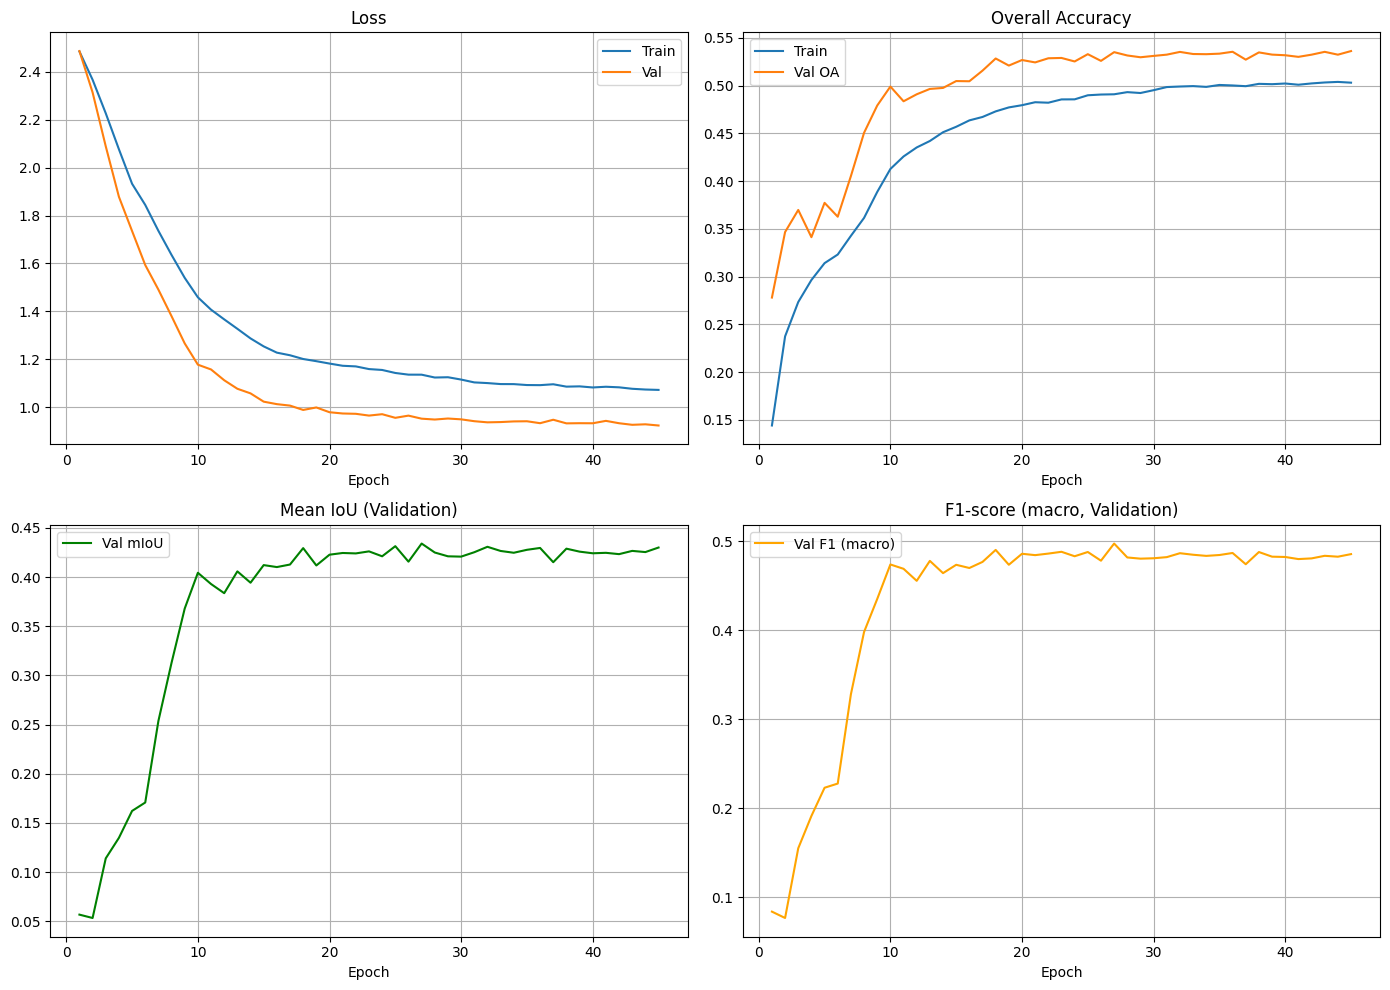

[✔] Training curves saved.

TEST SET EVALUATION (best model)
  Overall Accuracy : 0.5388
  Mean IoU         : 0.4404
  F1 (macro)       : 0.5030
  Per-class IoU    :
      Class 0 : IoU=0.9871  F1=0.9935
      Class 1 : IoU=0.9073  F1=0.9514
      Class 2 : IoU=0.8361  F1=0.9107
      Class 3 : IoU=0.9109  F1=0.9534
      Class 4 : IoU=0.7967  F1=0.8868
      Class 5 : IoU=0.8314  F1=0.9080
      Class 6 : IoU=0.0085  F1=0.0168
      Class 7 : IoU=0.1574  F1=0.2720
      Class 8 : IoU=0.2559  F1=0.4075
      Class 9 : IoU=0.0000  F1=0.0000
      Class 10 : IoU=0.1314  F1=0.2322
      Class 11 : IoU=0.0000  F1=0.0000
      Class 12 : IoU=0.0000  F1=0.0000
      Class 13 : IoU=0.3423  F1=0.5100
[✔] Test metrics saved to test_metrics.json


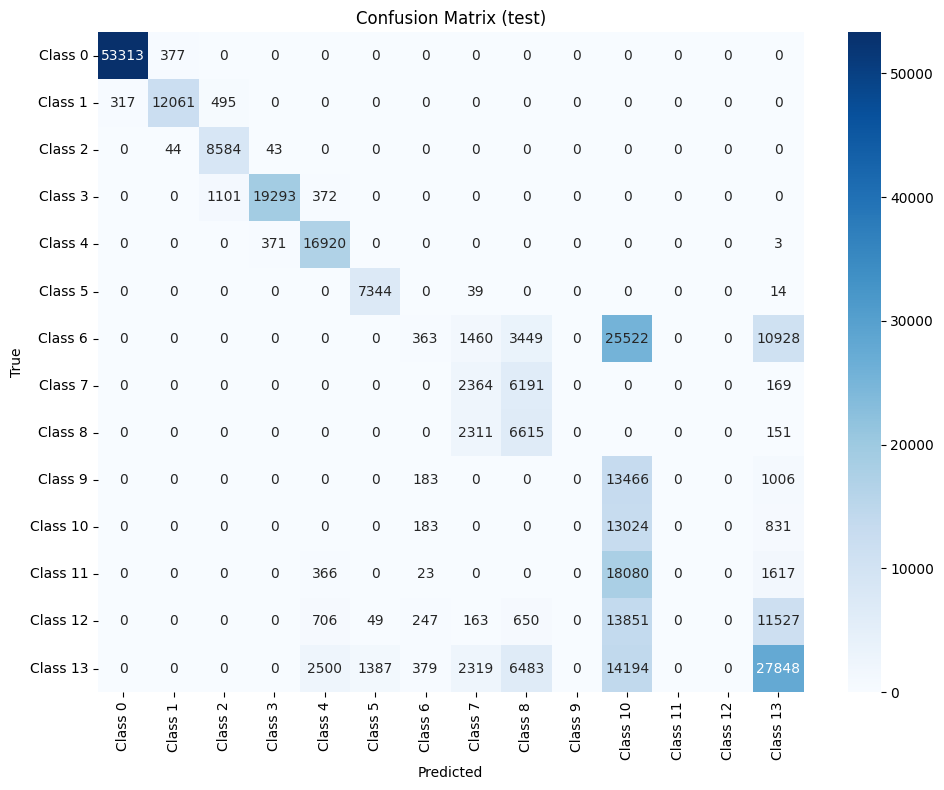

[✔] Confusion matrix (test) saved.
[✔] Per-class IoU bar chart (test) saved.

INFERENCE ON HELD-OUT FILE: valve_0328_lidar_classes.ply
  Overall Accuracy : 0.5359
  Mean IoU         : 0.4303
  F1 (macro)       : 0.4881
  [✔] Ground truth saved: /content/output/holdout_ground_truth.ply
  [✔] Predictions  saved: /content/output/holdout_prediction.ply
  [✔] Error map saved: /content/output/holdout_error_map.ply


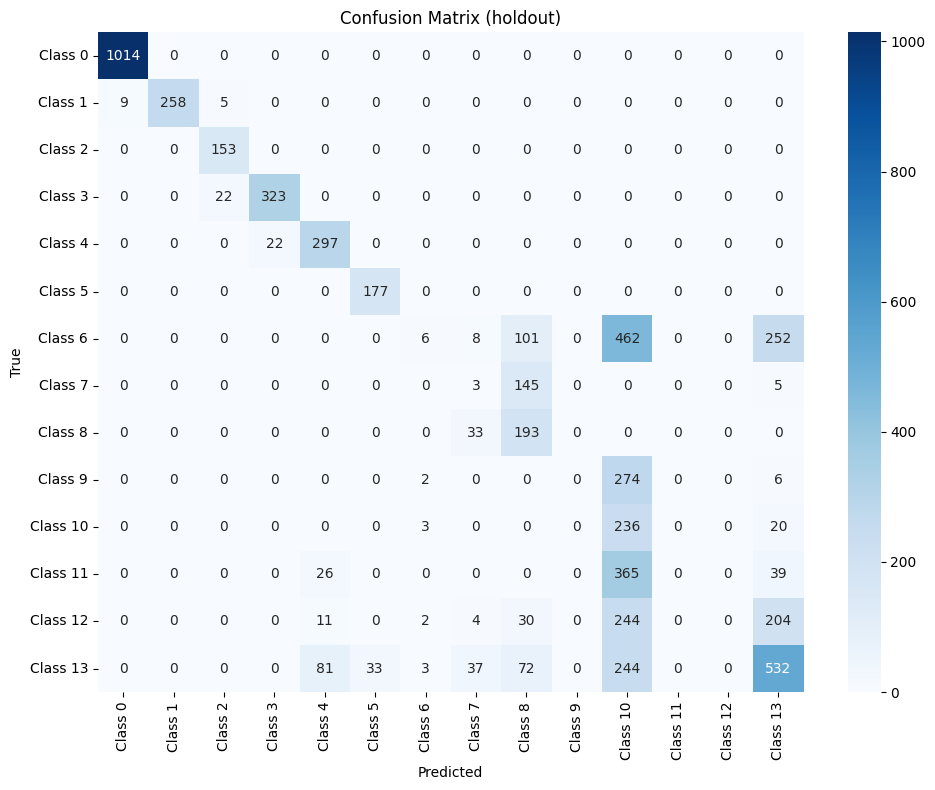

[✔] Confusion matrix (holdout) saved.

ALL DONE  (Point Transformer)


In [26]:
def main():
    # ── Gather files ──────────────────────────────────────────────────────────
    all_files = sorted(glob.glob(os.path.join(CFG["dataset_dir"], "*.ply")))
    assert len(all_files) > 0, f"No .ply files found in {CFG['dataset_dir']}"
    print(f"Found {len(all_files)} PLY files.")

    random.shuffle(all_files)
    holdout_file = all_files.pop()
    print(f"[!] Held-out file: {os.path.basename(holdout_file)}")

    # ── Investigate ───────────────────────────────────────────────────────────
    num_classes, classes, ce_weights = investigate_dataset(all_files)

    # ── Split ─────────────────────────────────────────────────────────────────
    n = len(all_files)
    n_train = int(n * CFG["train_ratio"])
    n_val = int(n * CFG["val_ratio"])
    train_files = all_files[:n_train]
    val_files = all_files[n_train:n_train + n_val]
    test_files = all_files[n_train + n_val:]
    print(f"Split: train={len(train_files)}, val={len(val_files)}, "
          f"test={len(test_files)}")

    # ── Datasets & Loaders ────────────────────────────────────────────────────
    train_ds = PointCloudDataset(train_files, CFG["num_points"], augment=True)
    val_ds = PointCloudDataset(val_files, CFG["num_points"], augment=False)
    test_ds = PointCloudDataset(test_files, CFG["num_points"], augment=False)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                              shuffle=True, num_workers=CFG["num_workers"],
                              pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"],
                            shuffle=False, num_workers=CFG["num_workers"],
                            pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"],
                             shuffle=False, num_workers=CFG["num_workers"],
                             pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    model = PointTransformerSeg(
        num_classes=num_classes,
        k=CFG["k"],
        dims=tuple(CFG["pt_dims"]),
        npoints=tuple(CFG["npoints"]),
        dropout=CFG["dropout"],
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Point Transformer parameters: {total_params:,}")

    # ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
    weight_tensor = torch.tensor(ce_weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"],
                                 weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                step_size=CFG["scheduler_step"],
                                                gamma=CFG["scheduler_gamma"])

    # ── Training Loop ─────────────────────────────────────────────────────────
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_oa": [], "val_miou": [], "val_f1": [],
    }
    best_miou = 0.0
    best_epoch = 0

    print("\n" + "=" * 70)
    print("TRAINING START  (Point Transformer)")
    print("=" * 70)

    for epoch in range(1, CFG["epochs"] + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
        val_metrics = evaluate(
            model, val_loader, criterion, DEVICE, num_classes)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_oa"].append(val_metrics["oa"])
        history["val_miou"].append(val_metrics["miou"])
        history["val_f1"].append(val_metrics["f1_macro"])

        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch:3d}/{CFG['epochs']}  "
              f"lr={lr_now:.6f}  "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
              f"val_loss={val_metrics['loss']:.4f}  "
              f"val_OA={val_metrics['oa']:.4f}  "
              f"val_mIoU={val_metrics['miou']:.4f}  "
              f"val_F1={val_metrics['f1_macro']:.4f}  "
              f"({elapsed:.1f}s)")

        if val_metrics["miou"] > best_miou:
            best_miou = val_metrics["miou"]
            best_epoch = epoch
            torch.save(model.state_dict(),
                       os.path.join(CFG["output_dir"], "best_model.pth"))
            print(f"  ► New best mIoU: {best_miou:.4f} — model saved.")

    print(f"\nBest val mIoU: {best_miou:.4f} at epoch {best_epoch}")
    torch.save(model.state_dict(),
               os.path.join(CFG["output_dir"], "last_model.pth"))

    # ── Plot training curves ──────────────────────────────────────────────────
    plot_training_curves(history, CFG["output_dir"])

    # ── Test Evaluation ───────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("TEST SET EVALUATION (best model)")
    print("=" * 70)

    model.load_state_dict(torch.load(
        os.path.join(CFG["output_dir"], "best_model.pth"),
        map_location=DEVICE))
    test_metrics = evaluate(model, test_loader, criterion, DEVICE, num_classes)

    print(f"  Overall Accuracy : {test_metrics['oa']:.4f}")
    print(f"  Mean IoU         : {test_metrics['miou']:.4f}")
    print(f"  F1 (macro)       : {test_metrics['f1_macro']:.4f}")
    print(f"  Per-class IoU    :")
    for c in range(num_classes):
        print(f"      Class {classes[c]} : "
              f"IoU={test_metrics['per_class_iou'][c]:.4f}  "
              f"F1={test_metrics['f1_per_class'][c]:.4f}")

    metrics_save = {
        "overall_accuracy": float(test_metrics["oa"]),
        "mean_iou": float(test_metrics["miou"]),
        "f1_macro": float(test_metrics["f1_macro"]),
        "per_class_iou": {str(classes[c]): float(test_metrics["per_class_iou"][c])
                          for c in range(num_classes)},
        "per_class_f1": {str(classes[c]): float(test_metrics["f1_per_class"][c])
                         for c in range(num_classes)},
        "best_epoch": best_epoch,
    }
    with open(os.path.join(CFG["output_dir"], "test_metrics.json"), "w") as f:
        json.dump(metrics_save, f, indent=2)
    print("[✔] Test metrics saved to test_metrics.json")

    plot_confusion_matrix(test_metrics["confusion_matrix"], classes,
                          CFG["output_dir"], tag="test")
    plot_per_class_iou(test_metrics["per_class_iou"], classes,
                       CFG["output_dir"], tag="test")

    # ── Inference on held-out file ────────────────────────────────────────────
    print("\n" + "=" * 70)
    print(f"INFERENCE ON HELD-OUT FILE: {os.path.basename(holdout_file)}")
    print("=" * 70)

    pts_ho, lbl_ho, pred_ho = infer_full_cloud(
        model, holdout_file, DEVICE, num_classes, CFG["num_points"])

    ho_metrics = compute_metrics(pred_ho, lbl_ho, num_classes)
    print(f"  Overall Accuracy : {ho_metrics['oa']:.4f}")
    print(f"  Mean IoU         : {ho_metrics['miou']:.4f}")
    print(f"  F1 (macro)       : {ho_metrics['f1_macro']:.4f}")

    gt_path = os.path.join(CFG["output_dir"], "holdout_ground_truth.ply")
    save_coloured_ply(gt_path, pts_ho, lbl_ho, CLASS_COLORS)
    print(f"  [✔] Ground truth saved: {gt_path}")

    pred_path = os.path.join(CFG["output_dir"], "holdout_prediction.ply")
    save_coloured_ply(pred_path, pts_ho, pred_ho, CLASS_COLORS)
    print(f"  [✔] Predictions  saved: {pred_path}")

    # Error map
    error_colors = np.zeros((len(pts_ho), 3), dtype=np.uint8)
    correct_mask = (pred_ho == lbl_ho)
    error_colors[correct_mask] = [0, 200, 0]
    error_colors[~correct_mask] = [255, 0, 0]
    err_path = os.path.join(CFG["output_dir"], "holdout_error_map.ply")
    N_ho = len(pts_ho)
    with open(err_path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {N_ho}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\n"
                "property uchar blue\n")
        f.write("end_header\n")
        for i in range(N_ho):
            f.write(f"{pts_ho[i,0]:.6f} {pts_ho[i,1]:.6f} "
                    f"{pts_ho[i,2]:.6f} "
                    f"{error_colors[i,0]} {error_colors[i,1]} "
                    f"{error_colors[i,2]}\n")
    print(f"  [✔] Error map saved: {err_path}")

    plot_confusion_matrix(ho_metrics["confusion_matrix"], classes,
                          CFG["output_dir"], tag="holdout")

    with open(os.path.join(CFG["output_dir"],
                           "training_history.json"), "w") as f:
        json.dump(history, f, indent=2)

    print("\n" + "=" * 70)
    print("ALL DONE  (Point Transformer)")
    print("=" * 70)


if __name__ == "__main__":
    main()